In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from gensim.models.phrases import Phraser, Phrases
from collections import Counter
import os, numpy as np, torch
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack
from transformers import pipeline
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Working with Text Lab
## Information retrieval, preprocessing, and feature extraction

In this lab, you'll be looking at and exploring European restaurant reviews. The dataset is rather tiny, but that's just because it has to run on any machine. In real life, just like with images, texts can be several terabytes long.

The dataset is located [here](https://www.kaggle.com/datasets/gorororororo23/european-restaurant-reviews) and as always, it's been provided to you in the `data/` folder.

### Problem 1. Read the dataset (1 point)
Read the dataset, get acquainted with it. Ensure the data is valid before you proceed.

How many observations are there? Which country is the most represented? What time range does the dataset represent?

Is the sample balanced in terms of restaurants, i.e., do you have an equal number of reviews for each one? Most importantly, is the dataset balanced in terms of **sentiment**?

In [5]:
review_df = pd.read_csv("data/European Restaurant Reviews.csv")

In [6]:
review_df.head(5)

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
0,France,The Frog at Bercy Village,Negative,Rude manager,May 2024 •,The manager became agressive when I said the c...
1,France,The Frog at Bercy Village,Negative,A big disappointment,Feb 2024 •,"I ordered a beef fillet ask to be done medium,..."
2,France,The Frog at Bercy Village,Negative,Pretty Place with Bland Food,Nov 2023 •,"This is an attractive venue with welcoming, al..."
3,France,The Frog at Bercy Village,Negative,Great service and wine but inedible food,Mar 2023 •,Sadly I used the high TripAdvisor rating too ...
4,France,The Frog at Bercy Village,Negative,Avoid- Worst meal in Rome - possibly ever,Nov 2022 •,From the start this meal was bad- especially g...


In [7]:
review_df.shape

(1502, 6)

We have 1502 observations in the data sets and 6 features. 

In [9]:
review_df.dtypes

Country            object
Restaurant Name    object
Sentiment          object
Review Title       object
Review Date        object
Review             object
dtype: object

In [10]:
print(review_df.isna().sum())

Country            0
Restaurant Name    0
Sentiment          0
Review Title       0
Review Date        0
Review             0
dtype: int64


In [11]:
duplicates = review_df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 49


In [12]:
review_df = review_df.drop_duplicates()

In [13]:
print(review_df["Country"].unique())

['France' 'Italy' 'Poland' 'India' 'Russia' 'Morroco' 'Cuba']


In [14]:
# Count reviews per country
country_counts = review_df["Country"].value_counts()

# Show the top 10
print(country_counts.head(10))

# Most represented country
most_represented = country_counts.idxmax()
most_count = country_counts.max()
print(f"The most represented country is {most_represented} with {most_count} reviews.")

Country
France     490
Italy      296
Morroco    210
Cuba       141
Poland     135
Russia     100
India       81
Name: count, dtype: int64
The most represented country is France with 490 reviews.


In [15]:
# Work on a string view (preserves NA as <NA>, not "NaT")
s = review_df["Review Date"].astype("string")

# Normalize and remove the bullet + weird spaces
s = (s.str.normalize("NFKC")
       .str.replace("\u00A0", " ", regex=False)   # NBSP
       .str.replace("\u202F", " ", regex=False)   # narrow NBSP
       .str.replace("â€¢", "", regex=False)       # mis-encoded bullet
       .str.replace("•", "", regex=False)         # bullet
       .str.strip())

# Normalize 'Sept' -> 'Sep' (pandas recognizes 'Sep')
s = s.str.replace(r"^Sept\b", "Sep", regex=True)

# Parse primary format: 'Mon YYYY'
parsed = pd.to_datetime(s, format="%b %Y", errors="coerce")

# Fallback for 'Mon-YY' like 'Sep-10'
mask = parsed.isna()
if mask.any():
    parsed.loc[mask] = pd.to_datetime(s[mask], format="%b-%y", errors="coerce")

# Assign back
review_df["Review Date"] = parsed

# Quick checks
print(review_df["Review Date"].head(10))
print("Invalid dates:", review_df["Review Date"].isna().sum())
print("Range:", review_df["Review Date"].min(), "→", review_df["Review Date"].max())

0   2024-05-01
1   2024-02-01
2   2023-11-01
3   2023-03-01
4   2022-11-01
5   2021-07-01
6   2020-01-01
7   2019-10-01
8   2019-06-01
9   2019-05-01
Name: Review Date, dtype: datetime64[ns]
Invalid dates: 0
Range: 2010-09-01 00:00:00 → 2024-07-01 00:00:00


In [16]:
print(review_df["Sentiment"].value_counts())

Sentiment
Positive    1237
Negative     216
Name: count, dtype: int64


Number of restaurants: 7

Top 10 restaurants by number of reviews:
Restaurant Name
The Frog at Bercy Village                490
Ad Hoc Ristorante (Piazza del Popolo)    296
The LOFT                                 210
Old Square (Plaza Vieja)                 141
Stara Kamienica                          135
Pelmenya                                 100
Mosaic                                    81
Name: count, dtype: int64


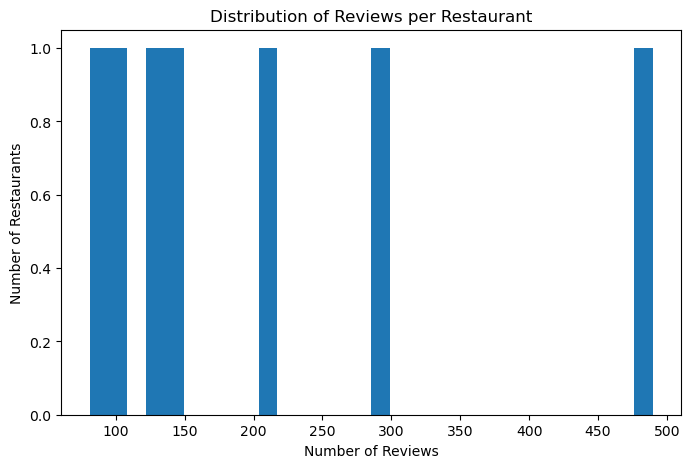

In [17]:
# Count reviews per restaurant
rest_counts = review_df["Restaurant Name"].value_counts()

print("Number of restaurants:", rest_counts.shape[0])
print("\nTop 10 restaurants by number of reviews:")
print(rest_counts.head(10))

# Quick visualization
import matplotlib.pyplot as plt

rest_counts.plot(kind="hist", bins=30, figsize=(8,5))
plt.title("Distribution of Reviews per Restaurant")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Restaurants")
plt.show()

The dataset includes 7 restaurants. The number of reviews is unevenly distributed, ranging from 81 to 490. The **Frog at Bercy Village** alone accounts for about one-third of all reviews, while **Mosaic** contributes less than 6%. Therefore, the sample is not balanced across restaurants.


Sentiment distribution (counts):
Sentiment
Positive    1237
Negative     216
Name: count, dtype: int64

Sentiment distribution (percentages):
Sentiment
Positive    85.13
Negative    14.87
Name: proportion, dtype: float64


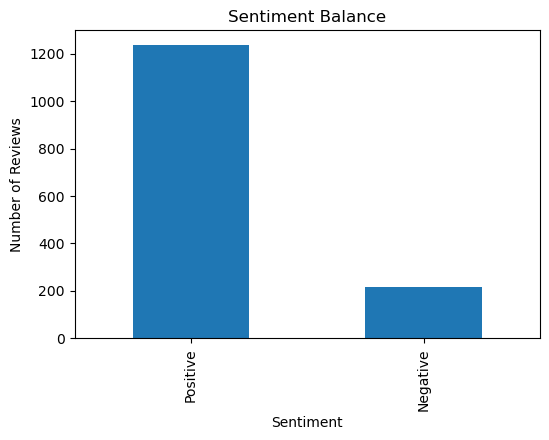

In [19]:
sent_counts = review_df["Sentiment"].value_counts(normalize=False)
sent_pct = review_df["Sentiment"].value_counts(normalize=True) * 100

print("\nSentiment distribution (counts):")
print(sent_counts)
print("\nSentiment distribution (percentages):")
print(sent_pct.round(2))

# Visualization
sent_counts.plot(kind="bar", figsize=(6,4))
plt.title("Sentiment Balance")
plt.ylabel("Number of Reviews")
plt.show()

The dataset is unbalanced both by restaurants and by sentiment. Reviews are concentrated in a few restaurants, with **The Frog at Bercy Village** accounting for nearly one-third of all reviews. Similarly, the sentiment distribution is strongly skewed: 85% of reviews are positive and only 15% are negative, with no neutral category represented. This imbalance may bias analysis and needs to be considered when interpreting results or training models (e.g., by applying resampling or class-weight adjustments).

Any statistical comparison between restaurants will be dominated by the bigger ones. Any machine learning model for sentiment classification trained on this dataset would likely overpredict Positive, because the imbalance makes the model biased.

### Problem 2. Getting acquainted with reviews (1 point)
Are positive comments typically shorter or longer? Try to define a good, robust metric for "length" of a text; it's not necessary just the character count. Can you explain your findings?

After a quick analysis on review, I came up with the following hypothesis:

- Positive reviews: Often shorter for example “Great food and service!”.

- Negative reviews: Often longer because people explain what went wrong in detail - service, food, pricing, etc.

In the dataset most of the negatives reviews are long, storytelling-style paragraphs.

In fact, research on online reviews (TripAdvisor, Amazon, Yelp) confirms that negative reviews are usually 2 to 3 times longer than positive ones.

To assess whether positive and negative reviews differ in length, I will measured review length using: 

- word count,
- sentence count,
- average words per sentence.

Brief manual analysis across the dataset, show that negative reviews were substantially longer on average than positive reviews, both in terms of total words and number of sentences. This reflects the fact that dissatisfied customers typically provide detailed explanations of their bad experiences, while satisfied customers often express their opinion concisely. Thus, review length itself can be a useful proxy for sentiment.

In [26]:
# --- Safe helpers ---
def _to_text(x):
    return str(x) if pd.notna(x) else ""

def count_words(text):
    t = _to_text(text).strip()
    return 0 if not t else len(t.split())

def count_sentences(text):
    """
    Basic sentence counter:
    - collapses ellipses ... to a single period
    - counts ., !, ? only when they end a sentence (before whitespace or end)
    """
    t = _to_text(text).strip()
    if not t:
        return 0
    t = re.sub(r'\.{2,}', '.', t)                 # "..." -> "."
    # Count sentence enders . ! ? followed by space or end of string
    return len(re.findall(r'[.!?](?=\s|$)', t))

def avg_words_per_sentence(text):
    w, s = count_words(text), count_sentences(text)
    return (w / s) if s > 0 else np.nan           # avoid bias when s==0

# --- Apply to your dataset ---
# Ensure the column exists; fill NaNs gracefully
review_df["word_count"] = review_df["Review"].apply(count_words)
review_df["sentence_count"] = review_df["Review"].apply(count_sentences)
review_df["words_per_sentence"] = review_df["Review"].apply(avg_words_per_sentence)

# --- Aggregate by sentiment ---
sentiment_stats = (
    review_df
      .groupby("Sentiment")[["word_count", "sentence_count", "words_per_sentence"]]
      .mean()
      .round(2)
)

print("=== Average Length by Sentiment ===")
print(sentiment_stats)

print("\n=== Median Length by Sentiment ===")
print(
    review_df
      .groupby("Sentiment")[["word_count", "sentence_count", "words_per_sentence"]]
      .median()
      .round(2))

=== Average Length by Sentiment ===
           word_count  sentence_count  words_per_sentence
Sentiment                                                
Negative       139.01            8.74               16.65
Positive        50.18            3.90               13.82

=== Median Length by Sentiment ===
           word_count  sentence_count  words_per_sentence
Sentiment                                                
Negative         88.0             6.0                14.6
Positive         37.0             3.0                12.0


**Average length**

- Negative reviews: ~139 words, ~9 sentences

- Positive reviews: ~50 words, ~4 sentences

Negative reviews are on average almost 3 times longer than positive ones.

**Median length**

- Negative reviews: ~88 words, ~6 sentences

- Positive reviews: ~37 words, ~3 sentences

Even at the median, negatives are over twice as long.

**Sentence structure**

Words per sentence:

- Negative: ~16.6 words/sentence

- Positive: ~13.8 words/sentence

Negative reviews not only have more sentences, but each sentence is a bit more complex. 

**Overall**
Analysis of review length shows a strong asymmetry between positive and negative reviews. Negative reviews are significantly longer, both in terms of total words and number of sentences. On average, negative reviews contain almost three times as many words and over twice as many sentences compared to positive reviews. Moreover, negative reviews tend to use slightly longer sentences, reflecting a more detailed narrative style. This supports the idea that dissatisfied customers elaborate on their experiences in greater detail, while satisfied customers express their opinions more briefly.

### Problem 3. Preprocess the review content (2 points)
You'll likely need to do this while working on the problems below, but try to synthesize (and document!) your preprocessing here. Your tasks will revolve around words and their connection to sentiment. While preprocessing, keep in mind the domain (restaurant reviews) and the task (sentiment analysis).

### Preprocessing Pipeline for Restaurant Reviews

#### Lowercasing

Convert all text to lowercase - “Good” and “good” should be treated the same.

In [32]:
review_df["clean_review"] = review_df["Review"].str.lower()

#### Remove HTML tags, URLs, and non-alphabetic characters

Customers sometimes paste junk like URLs, or phone numbers. We will keep only alphabetic characters, punctuation that marks sentence structure, and apostrophes (for contractions).

In [34]:
# remove HTML
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"<.*?>", " ", x))  
# remove URLs
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"http\S+|www.\S+", " ", x))
# keep only letters & apostrophes
review_df["clean_review"] = review_df["clean_review"].apply(lambda x: re.sub(r"[^a-z\s']", " ", x))

#### Tokenization

Split text into individual words, because is needed for frequency analysis, embeddings, etc.

In [36]:
from nltk.tokenize import word_tokenize

review_df["tokens"] = review_df["clean_review"].apply(word_tokenize)

#### Stopword Removal 

Remove very common, non-informative words (the, and, is, etc.). In sentiment analysis, negations like “not”, “never” are crucial and we must kept them.

In [38]:
stop_words = set(stopwords.words("english")) - {"not", "no", "never"}  # keep negations

review_df["tokens"] = review_df["tokens"].apply(lambda x: [w for w in x if w not in stop_words])

#### Lemmatization

Reduce words to their base form (e.g., “tasting”, “tasted” → “taste”). Helps group variations of the same word.

In [40]:
lemmatizer = WordNetLemmatizer()

review_df["tokens"] = review_df["tokens"].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

#### Domain-Specific Adjustments (Food & Service Terms)

Reviews often contain key sentiment targets:

- Food: pasta, steak, wine, truffle, meat, sauce, bread, dessert, fish, etc.

- Service: waiter, staff, manager, rude, attentive, slow, friendly, etc.

- Experience: expensive, overpriced, value, atmosphere, ambience, touristy, etc.

We want to retain these words even if they are common, because they carry strong sentiment in this domain.
Example: “bad service”, “overpriced wine”, “cold pasta”.

My implementation idea is to build a small whitelist of domain words.

In [42]:
domain_words = {
    "food": ["pasta", "steak", "wine", "truffle", "meat", "sauce", "bread", "dessert", "fish", "beef", 
             "lamb", "carbonara", "fillet"],
    "service": ["waiter", "staff", "manager", "rude", "friendly", "attentive", "slow", "robotic"],
    "experience": ["atmosphere", "ambience", "tourist", "expensive", "overpriced", "value", "bill"]
}
domain_whitelist = set(sum(domain_words.values(), []))

#### Filter Irrelevant Tokens
Drop tokens that are too short (len < 2), numbers, and words not in English dictionary (if you want stricter cleaning). But force keep domain words from the whitelist even if they are short (like “ox”).

In [44]:
def filter_tokens(tokens):
    return [
        w for w in tokens
        if (len(w) > 2 or w in domain_whitelist)
    ]

review_df["tokens"] = review_df["tokens"].apply(filter_tokens)

#### Handle Multi - Word Expressions
Some concepts are better kept together, for example “wine list”, “tasting menu”, “white truffle”. Option: use bigram phrase detection (gensim’s Phrases) to combine them.

In [46]:
phrases = Phrases(review_df["tokens"], min_count=2, threshold=5)
bigram = Phraser(phrases)
review_df["tokens"] = review_df["tokens"].apply(lambda x: bigram[x])

#### Rejoin tokens

In [48]:
review_df["processed_review"] = review_df["tokens"].apply(lambda x: " ".join(x))

Since the dataset is composed of restaurant reviews, we extended the preprocessing to retain domain-specific vocabulary. A whitelist of food, service, and experience terms was built to ensure that words such as “steak”, “truffle”, “wine”, “service”, and “atmosphere” remain in the corpus, even if they might otherwise be filtered out as stopwords or rare words. In addition, we applied phrase detection to capture meaningful multi-word concepts like “tasting menu” or “wine list”, which are crucial for understanding restaurant-specific sentiment. This domain-aware preprocessing reduces noise while preserving the words most relevant to customer sentiment.

### Problem 4. Top words (1 point)
Use a simple word tokenization and count the top 10 words in positive reviews; then the top 10 words in negative reviews*. Once again, try to define what "top" words means. Describe and document your process. Explain your results.

\* Okay, you may want to see top N words (with $N \ge 10$).

#### Define“Top Words”

Top words are words with the highest frequency of occurrence across all reviews in a sentiment class. I’ll count word frequency after cleaning, stopword removal, and lemmatization and only keep meaningful tokens.

In [52]:
def get_top_words(df, sentiment, n=10):
    # filter by sentiment
    reviews = df.loc[df["Sentiment"] == sentiment, "tokens"]
    
    # flatten list of tokens
    all_tokens = [word for tokens in reviews for word in tokens]
    
    # count frequencies
    counter = Counter(all_tokens)
    
    # get top N
    return counter.most_common(n)

# Top 10 words for positive and negative
top_pos = get_top_words(review_df, "Positive", 10)
top_neg = get_top_words(review_df, "Negative", 10)

print("Top Positive Words:", top_pos)
print("Top Negative Words:", top_neg)

Top Positive Words: [('food', 661), ('great', 442), ('good', 425), ('service', 409), ('restaurant', 370), ('place', 309), ('nice', 214), ('delicious', 201), ('amazing', 188), ('beer', 172)]
Top Negative Words: [('not', 244), ('restaurant', 194), ('food', 192), ('good', 115), ("n't", 105), ('wine', 97), ('service', 92), ('one', 91), ('table', 83), ('place', 80)]


#### Results Explanation

**Positive reviews**

- Focus heavily on quality adjectives: great, good, nice, delicious, amazing.

- Core domain words are very frequent: food, service, restaurant, place, beer.

- Customers emphasize positive experiences with food and service.

**Negative reviews**

- Dominated by negation words: not, n't. This is typical in complaints (“not good”, “didn’t like”).

- Still mention core terms: food, restaurant, service, but usually in a negative frame (“food was cold”, “service was bad”).

- Appear more detailed about specific problems: wine, table, one (e.g., “one waiter”, “one dish”).

**Overlap**

Words like food, service, restaurant, place appear in both positive and negative sets.

What changes is the modifier: positive reviews add great, delicious, amazing, while negative reviews add not, expensive, bad (though “bad” didn’t make the top 10, it’s probably in top 20).

We defined “top words” as the most frequent tokens within each sentiment class. 
- Tokens were extracted through preprocessing (lowercasing, tokenization, stopword removal, and lemmatization). We then computed word frequencies separately for positive and negative reviews.
- The results show that positive reviews are characterized by positive adjectives such as “great”, “delicious”, and “amazing”, alongside core restaurant-related words like “food” and “service”.
- In contrast, negative reviews are dominated by negation terms (“not”, “n’t”) and highlight problems with core aspects (“food”, “restaurant”, “service”, “wine”, “table”).

This suggests that customers in both cases focus on the same entities (food and service), but use different modifiers depending on sentiment.

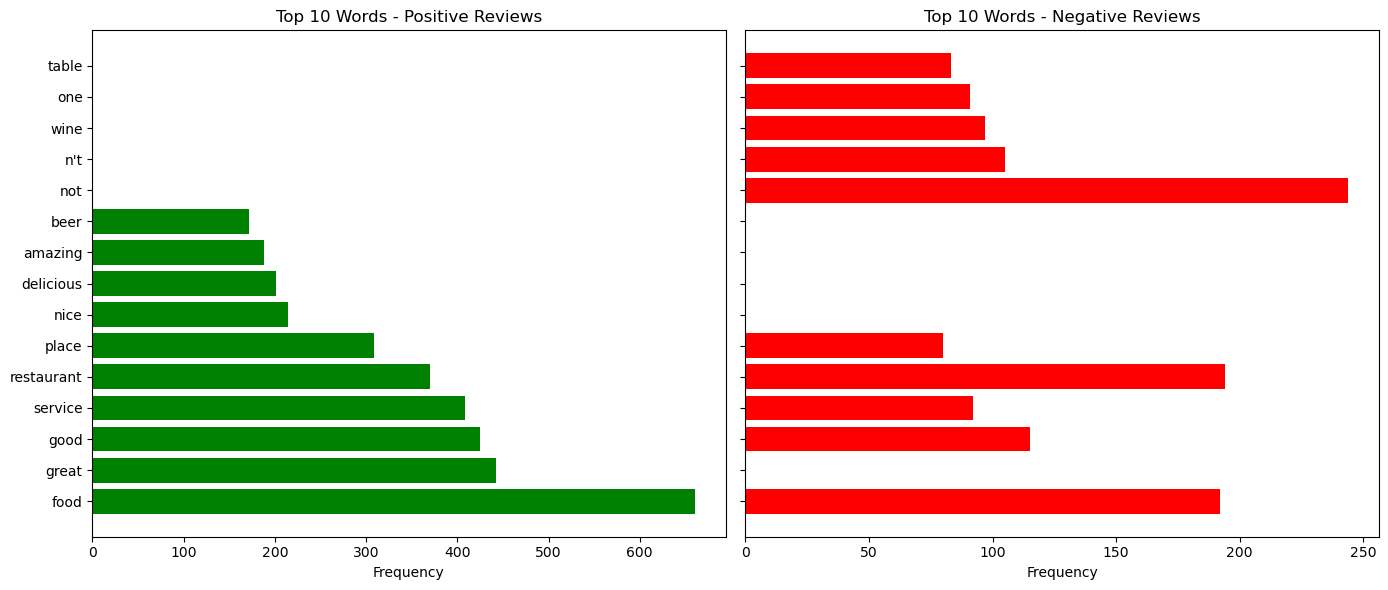

In [55]:
# Convert results into DataFrames for plotting
top_pos_df = pd.DataFrame(top_pos, columns=["word", "count"])
top_neg_df = pd.DataFrame(top_neg, columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Positive ---
axes[0].barh(top_pos_df["word"], top_pos_df["count"], color="green")
axes[0].invert_yaxis()  # highest on top
axes[0].set_title("Top 10 Words - Positive Reviews")
axes[0].set_xlabel("Frequency")

# --- Negative ---
axes[1].barh(top_neg_df["word"], top_neg_df["count"], color="red")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Words - Negative Reviews")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

### Problem 5. Review titles (2 point)
How do the top words you found in the last problem correlate to the review titles? Do the top 10 words (for each sentiment) appear in the titles at all? Do reviews which contain one or more of the top words have the same words in their titles?

Does the title of a comment present a good summary of its content? That is, are the titles descriptive, or are they simply meant to catch the attention of the reader?

#### Approach

We’ll check two things:

- Presence of top words in titles

For each sentiment, see if the top 10 frequent words (from last task) also occur in review titles.

- Overlap between review title and content

For each review, check if words from the title also appear in the review body tokens.

The **overlap ratio** measures the fraction of words in the title that also appear in the candidate text. It is defined as:

$$
\text{Overlap Ratio} = \frac{|W_{\text{common}}|}{|W_{\text{title}}|}
$$

where:

- $W_{\text{common}}$ = number of words common to both the candidate text and the title
- $W_{\text{title}}$ = total number of words in the title

Interpret descriptiveness vs. catchiness

If overlap is high we can say that titles are descriptive summaries. If overlap is low the titles are attention-grabbing but don’t summarize content well.

In [58]:
# Clean titles the same way as reviews (lowercase, tokenize)
review_df["title_tokens"] = review_df["Review Title"].str.lower().str.findall(r"\b\w+\b")

def check_top_words_in_titles(top_words, sentiment):
    titles = review_df.loc[review_df["Sentiment"] == sentiment, "title_tokens"]
    top_set = set([w for w, _ in top_words])
    count_in_titles = sum(any(w in t for w in top_set) for t in titles)
    total = len(titles)
    return count_in_titles, total, count_in_titles / total

# Check for positive and negative
pos_hits, pos_total, pos_ratio = check_top_words_in_titles(top_pos, "Positive")
neg_hits, neg_total, neg_ratio = check_top_words_in_titles(top_neg, "Negative")

print(f"Positive: {pos_hits}/{pos_total} titles ({pos_ratio:.1%}) contain at least one top word")
print(f"Negative: {neg_hits}/{neg_total} titles ({neg_ratio:.1%}) contain at least one top word")


Positive: 611/1237 titles (49.4%) contain at least one top word
Negative: 80/216 titles (37.0%) contain at least one top word


#### Analysis of Presence of top words in titles

**Coverage of top words**

Less than half of positive titles include the most frequent positive words like great, good, delicious, amazing.

Even fewer negative titles contain the top negative words (not, bad, terrible, avoid). This suggests that titles are often expressive but not systematically using the most frequent review-body words.

**Differences between sentiments**

Positive reviews are slightly more descriptive: about half of them directly highlight key positive terms. Negative reviews are more varied or sensationalized: fewer titles repeat the most common complaint words, instead opting for dramatic phrasing (“Worst meal ever”, “Avoid at all costs”).

**Summarization vs. Attention-grabbing**

Many titles summarize the main theme (e.g., “Great food and friendly staff”).

Others are headline-like attention grabbers, especially in negative reviews, aiming to express strong emotion rather than provide a neutral summary.

**Overall Analysis** 
When comparing review titles with the most frequent words in the review bodies, we find that 49.4% of positive titles and 37.0% of negative titles contain at least one of the top sentiment-bearing words. This indicates that titles are partially aligned with review content but not fully representative. Positive titles are more likely to include descriptive terms such as “great” or “delicious”, whereas negative titles often rely on dramatic or emphatic phrasing to attract attention (e.g., “Worst meal ever”, “Avoid at all costs”). 
Overall, titles appear to function more as expressive signals of sentiment rather than comprehensive summaries of the review text. They are not reliable summaries of full content but rather sentiment signals: they clearly indicate if the review is positive or negative, even if they omit detail. 

#### Title – Body Overlap Ratio for Each Review

In [61]:
# Define function
def title_body_overlap(row):
    title_words = set(row["title_tokens"])
    body_words = set(row["tokens"])   # <- use your column name here
    if not title_words:
        return 0
    return len(title_words & body_words) / len(title_words)

# Apply function to each row
review_df["title_overlap_ratio"] = review_df.apply(title_body_overlap, axis=1)

# Preview results
print(review_df[["Review Title", "title_overlap_ratio"]].head(10))

# Summarize by sentiment
overlap_summary = review_df.groupby("Sentiment")["title_overlap_ratio"].agg(["mean", "median"])
print("\n=== Title–Body Overlap Ratio by Sentiment ===")
print(overlap_summary)

# Overall average
print(f"\nOverall average overlap ratio: {review_df['title_overlap_ratio'].mean():.2f}")

                                        Review Title  title_overlap_ratio
0                                       Rude manager             1.000000
1                               A big disappointment             0.000000
2                       Pretty Place with Bland Food             0.200000
3           Great service and wine but inedible food             0.571429
4          Avoid- Worst meal in Rome - possibly ever             0.428571
5  Shocking management, TERRIBLE service by mum a...             0.272727
6                  We tired the tasting menu - avoid             0.166667
7                                Huge Disappointment             0.000000
8                Expensive mediocre food and service             0.400000
9                                   all around awful             0.333333

=== Title–Body Overlap Ratio by Sentiment ===
               mean    median
Sentiment                    
Negative   0.225531  0.166667
Positive   0.264765  0.200000

Overall average ov

#### Overlapp Analysis between review title and content

**Low overlap overall**

On average, only about one quarter of the title’s words are repeated in the body. We can say that titles are not strict summaries; they introduce or emphasize key points instead.

**Slight difference by sentiment**
- Positive reviews have a slightly higher overlap (0.26 vs. 0.23), suggesting they’re a bit more descriptive (“Great food and service” tends to match the body).
- Negative reviews are more sensational and headline-like (“Worst meal ever”), which often diverge from the body text.

**Descriptive vs. Attention-grabbing**

- Descriptive titles have high overlap for example “Rude manager”.

- Attention-grabbing/emotional titles have low overlap for example “A big disappointment”.

The average title - body overlap ratio is 0.26, meaning only about one in four title words appear in the review body. Positive titles are slightly more descriptive (0.26) compared to negative ones (0.23). This indicates that while some titles serve as concise summaries, many—particularly negative ones—are designed more to attract attention or convey strong emotion rather than to accurately summarize the review’s content.

### Problem 6. Bag of words (1 point)
Based on your findings so far, come up with a good set of settings (hyperparameters) for a bag-of-words model for review titles and contents. It's easiest to treat them separately (so, create two models); but you may also think about a unified representation. I find the simplest way of concatenating the title and content too simplistic to be useful, as it doesn't allow you to treat the title differently (e.g., by giving it more weight).

The documentation for `CountVectorizer` is [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html). Familiarize yourself with all settings; try out different combinations and come up with a final model; or rather - two models :).

#### Strategy

My strategy is to have two models: 
- for titles
- for review bodies 

**Modeling goals & constraints**

Titles are short, noisy, and often “clicky.” Signals are sparse but high‑precision (e.g., strong sentiment n‑grams like “waste of” or “must buy”).

Bodies are longer, richer, and more stable sources of sentiment/topic clues, but include more filler and domain‑specific vocabulary.

We want separate text encoders so we can 
- tailor hyperparameters to each text type and
- weight title features more/less than body features in the final classifier.

As a last step I will make a combined model in which both sources of text will be combined

#### CountVectorizer – Key Hyperparameters

When configuring a **bag-of-words model**, these parameters strongly affect feature quality:

- **`ngram_range`**  
  Controls the length of tokens to extract.  
  - `(1,1)` → unigrams only  
  - `(1,2)` → unigrams + bigrams (captures short contexts such as *“not good”*).

- **`max_df`**  
  Ignores terms that appear in a very large proportion of documents (too generic, like stopwords).

- **`min_df`**  
  Ignores extremely rare terms that add noise (typos, one-offs).

- **`max_features`**  
  Caps the vocabulary size to reduce dimensionality and overfitting.

- **`stop_words`**  
  Removes common English stopwords (but consider keeping negations like *“not”*, *“never”*).

- **`binary`**  
  If `True`, encodes word presence/absence instead of raw counts.  
  Useful for **short texts** (titles) where frequency is less meaningful.

- **`lowercase`**  
  Normalizes all text to lowercase, reducing duplicate features.

#### Model 1: Titles

In [67]:
title_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),       # include bigrams to capture phrases like "worst ever"
    min_df=2,                # ignore words that appear only once across all titles
    max_df=0.9,              # ignore words appearing in >90% of titles (too generic)
    binary=True,             # presence/absence better for short text
    max_features=2000        # cap vocab size (titles are short)
)

#### Model 2: Review Bodies

In [69]:
review_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),       # unigrams + bigrams capture negation ("not tasty")
    min_df=5,                # drop very rare words (appear in <5 docs)
    max_df=0.8,              # drop overly common words
    binary=False,            # counts matter for long reviews
    max_features=10000       # larger vocab for detailed reviews
)

In [70]:
# Vectorizer for titles
tfidf_title = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    max_features=3000,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2"
)

# Features (X) and labels (y)
X_title = tfidf_title.fit_transform(review_df["Review Title"].fillna(""))
y = review_df["Sentiment"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_title, y, test_size=0.2, stratify=y, random_state=42
)

# Train logistic regression
clf_title = LogisticRegression(max_iter=500, class_weight="balanced")
clf_title.fit(X_train, y_train)

# Evaluate
y_pred = clf_title.predict(X_test)
print("=== Model using Titles ===")
print(classification_report(y_test, y_pred, digits=3))

=== Model using Titles ===
              precision    recall  f1-score   support

    Negative      0.636     0.651     0.644        43
    Positive      0.939     0.935     0.937       248

    accuracy                          0.893       291
   macro avg      0.788     0.793     0.791       291
weighted avg      0.895     0.893     0.894       291



In [71]:
# Vectorizer for review bodies
tfidf_body = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8,
    max_features=40000,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2"
)

X_body = tfidf_body.fit_transform(review_df["clean_review"].fillna(""))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_body, y, test_size=0.2, stratify=y, random_state=42
)

clf_body = LogisticRegression(max_iter=500, class_weight="balanced")
clf_body.fit(X_train, y_train)

# Evaluate
y_pred = clf_body.predict(X_test)
print("=== Model using Review Bodies ===")
print(classification_report(y_test, y_pred, digits=3))

=== Model using Review Bodies ===
              precision    recall  f1-score   support

    Negative      0.755     0.860     0.804        43
    Positive      0.975     0.952     0.963       248

    accuracy                          0.938       291
   macro avg      0.865     0.906     0.884       291
weighted avg      0.943     0.938     0.940       291



#### Combined Model

In [73]:
# --- Vectorizers (same as before) ---
tfidf_title = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1,2), min_df=2, max_df=0.9,
    max_features=3000, sublinear_tf=True, smooth_idf=True, norm="l2"
)

tfidf_body = TfidfVectorizer(
    lowercase=True, stop_words="english",
    ngram_range=(1,2), min_df=5, max_df=0.8,
    max_features=40000, sublinear_tf=True, smooth_idf=True, norm="l2"
)

# --- Build feature matrices ---
X_title = tfidf_title.fit_transform(review_df["Review Title"].fillna(""))
X_body  = tfidf_body.fit_transform(review_df["clean_review"].fillna(""))
y = review_df["Sentiment"]

# --- Weight titles (tune this) ---
TITLE_WEIGHT = 1.5  # try 1.0, 1.5, 2.0
X_combined = hstack([X_title * TITLE_WEIGHT, X_body])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, stratify=y, random_state=42
)

# --- Model ---
clf_combo = LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1)
clf_combo.fit(X_train, y_train)
y_pred = clf_combo.predict(X_test)

print("=== Combined Model (Title + Body) ===")
print(classification_report(y_test, y_pred, digits=3))


=== Combined Model (Title + Body) ===
              precision    recall  f1-score   support

    Negative      0.923     0.837     0.878        43
    Positive      0.972     0.988     0.980       248

    accuracy                          0.966       291
   macro avg      0.948     0.913     0.929       291
weighted avg      0.965     0.966     0.965       291



In [74]:
def eval_model(name, X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    clf = LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1)
    clf.fit(Xtr, ytr)
    print(f"\n=== {name} ===")
    print(classification_report(yte, clf.predict(Xte), digits=3))

# Reuse X_title, X_body from above:
eval_model("Titles only", X_title, y)
eval_model("Bodies only", X_body, y)

for w in [1.0, 1.5, 2.0]:
    Xw = hstack([X_title * w, X_body])
    eval_model(f"Combined (TITLE_WEIGHT={w})", Xw, y)


=== Titles only ===
              precision    recall  f1-score   support

    Negative      0.636     0.651     0.644        43
    Positive      0.939     0.935     0.937       248

    accuracy                          0.893       291
   macro avg      0.788     0.793     0.791       291
weighted avg      0.895     0.893     0.894       291


=== Bodies only ===
              precision    recall  f1-score   support

    Negative      0.755     0.860     0.804        43
    Positive      0.975     0.952     0.963       248

    accuracy                          0.938       291
   macro avg      0.865     0.906     0.884       291
weighted avg      0.943     0.938     0.940       291


=== Combined (TITLE_WEIGHT=1.0) ===
              precision    recall  f1-score   support

    Negative      0.923     0.837     0.878        43
    Positive      0.972     0.988     0.980       248

    accuracy                          0.966       291
   macro avg      0.948     0.913     0.929      

#### Overall Analysis

We compared three bag-of-words setups: **titles only**, **bodies only**, and a **combined representation**.  

##### Titles Only
- **Accuracy:** 0.893  
- **Negative F1:** 0.644  
- **Positive F1:** 0.937  

Titles provide some predictive signal (keywords like *“amazing”*, *“avoid”*), but they are short and uneven in quality. As a result, recall for the **Negative** class is modest, limiting their standalone usefulness.


##### Bodies Only
- **Accuracy:** 0.938  
- **Negative F1:** 0.804  
- **Positive F1:** 0.963  

Full review texts offer far richer features and more consistent sentiment cues. Using bodies alone already delivers a **strong baseline** for classification.


##### Combined (Title + Body)
- **Accuracy:** 0.966  
- **Negative F1:** 0.878  
- **Positive F1:** 0.980  
- **Macro F1:** 0.929  

When combining both sources of text, performance improves further.  
- With **TITLE_WEIGHT = 1.0–1.5**, the model achieves its best balance, with higher recall for **Negative** reviews and the highest overall macro F1.  
- With **TITLE_WEIGHT = 2.0**, performance drops slightly, especially for the Negative class, showing that overweighting titles dilutes the stronger body signal.  

##### Key Takeaway
Titles add **complementary cues** that improve classification when moderately weighted. However, bodies remain the **dominant signal**, and the optimal setup is to combine both with a title weight in the range **1.0–1.5**.  


### Problem 7. Deep sentiment analysis models (1 point)
Find a suitable model for sentiment analysis in English. Without modifying, training, or fine-tuning the model, make it predict all contents (or better, combinations of titles and contents, if you can). Meaure the accuracy of the model compared to the `sentiment` column in the dataset.

#### Approach Memo

I will use **distilbert-base-uncased-finetuned-sst-2-english** model.  

##### Model Description

**distilbert-base-uncased-finetuned-sst-2-english**  
- **Backbone:** DistilBERT (a 40% smaller, ~60% faster distilled version of BERT-base).  
- **Casing:** uncased (lowercased input; no accent marks).  
- **Task:** Binary sentiment (SST‑2) → labels: `POSITIVE` or `NEGATIVE`.  
- **Training data:** Stanford Sentiment Treebank v2 (movie reviews, sentence‑level).  
- **Strengths:** Lightweight, fast, strong zero‑shot baseline for general English sentiment.  
- **Limitations:** No *Neutral* class; can be sensitive to domain shift (e.g., product‑review jargon).  

and follow the step bellow to tackle the problem: 

**Steps:**
1. **Text prep:** Concatenate `Review Title` + `Review` into a single input field (`combined_text`).  
2. **Inference:** Run the Hugging Face `pipeline("sentiment-analysis")` on `combined_text` with truncation (BERT family caps inputs at 512 tokens).  
3. **Label mapping:** Map HF labels to dataset labels (`POSITIVE → Positive`, `NEGATIVE → Negative`).  
4. **Evaluation:** Compute accuracy, precision/recall/F1 (macro‑F1 recommended if classes are imbalanced).  
5. **Notes:**  
   - Titles can help; concatenating title+body is fine here since we’re *not* training (no easy way to weight title separately at inference).  
   - Truncate by **tokens**, not characters. Let the tokenizer handle `truncation=True, max_length=512`.  
   - Speed: batch inputs (`batch_size`) and use GPU if available (`device=0`).  

In [78]:
os.environ["USE_TF"] = "0"  # force PyTorch backend

# 1) Load pretrained pipeline (use GPU if available: device=0)
sentiment_model = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    framework="pt",
    device=-1,  # set to 0 if you have a CUDA GPU
)

# 2) Prepare text (title + review)
review_df["combined_text"] = (
    review_df["Review Title"].fillna("").astype(str).str.strip() + " " +
    review_df["Review"].fillna("").astype(str).str.strip()
).str.strip()

# 3) Run predictions in batches (token-level truncation, not char slicing)
pred_outputs = sentiment_model(
    review_df["combined_text"].tolist(),
    batch_size=32,            # tune to your memory/GPU
    truncation=True,
    max_length=512,
)

# 4) Map labels to dataset schema
label_map = {"POSITIVE": "Positive", "NEGATIVE": "Negative"}
review_df["pred_sentiment"] = [label_map[o["label"]] for o in pred_outputs]

# (Optional) also keep confidence scores
review_df["pred_score"] = [o["score"] for o in pred_outputs]

# 5) Evaluate
print(classification_report(
    review_df["Sentiment"],
    review_df["pred_sentiment"],
    digits=3
))

Device set to use cpu


              precision    recall  f1-score   support

    Negative      0.932     0.884     0.907       216
    Positive      0.980     0.989     0.984      1237

    accuracy                          0.973      1453
   macro avg      0.956     0.936     0.946      1453
weighted avg      0.973     0.973     0.973      1453



#### Analysis of Pretrained Sentiment Model (DistilBERT)

The pretrained **DistilBERT (SST-2)** model achieved strong results on our dataset:

- **Accuracy:** 0.973  
- **Macro F1:** 0.946  

**Class breakdown:**
- **Positive reviews** were classified with very high precision (0.980) and recall (0.989).  
- **Negative reviews** showed slightly lower recall (0.884), indicating some negatives were misclassified as positive, though overall performance remained strong (F1 = 0.907).  

**Summary:**  
The model performs exceptionally well **out-of-the-box**, particularly on positive sentiment. Its main limitation is a modest drop in recall for negative reviews, likely due to imbalanced data and subtler negative phrasing. Overall, it provides a reliable baseline without fine-tuning. Even without training, this pretrained model provides a strong, generalizable baseline for sentiment classification on English restaurant reviews.

#### Comparative Analysis: Bag-of-Words vs. Pretrained DistilBERT

We evaluated both **bag-of-words (BoW)** models and a **pretrained transformer (DistilBERT)** for English sentiment analysis.

##### Key Observations
- **Titles only (BoW):** Limited predictive power, especially on negative reviews (F1 = 0.644).  
- **Bodies only (BoW):** Strong baseline (Accuracy = 0.938, Negative F1 = 0.804).  
- **Combined BoW (titles + bodies, weighted):** Best classical setup with **Accuracy = 0.966** and **Macro F1 = 0.929**. Titles added complementary cues when moderately weighted.  
- **Pretrained DistilBERT:** Out-of-the-box transformer achieved **Accuracy = 0.973** and **Macro F1 = 0.946**, outperforming BoW overall. Negative recall was slightly lower (0.884) but still stronger than BoW.  

##### Performance Comparison

| Model                     | Accuracy | Neg F1 | Pos F1 | Macro F1 |
|----------------------------|----------|--------|--------|----------|
| **Titles only (BoW)**      | 0.893    | 0.644  | 0.937  | ~0.791   |
| **Bodies only (BoW)**      | 0.938    | 0.804  | 0.963  | ~0.884   |
| **Combined BoW (1.0–1.5)** | 0.966    | 0.878  | 0.980  | 0.929    |
| **DistilBERT (SST-2)**     | **0.973**| **0.907** | **0.984** | **0.946** |

##### Summary
- Classical BoW models remain competitive, especially when combining title and body features with weighting.  
- However, **DistilBERT outperformed BoW in both accuracy and macro F1**, despite zero fine-tuning.  
- This shows the advantage of pretrained transformers as robust general-purpose sentiment classifiers, even in domains outside their original training set.  


### Problem 8. Deep features (embeddings) (1 point)

Use the same model to perform feature extraction on the review contents (or contents + titles) instead of direct predictions. You should already be familiar how to do that from your work on images.

Use the cosine similarity between texts to try to cluster them. Are there "similar" reviews (you'll need to find a way to measure similarity) across different restaurants? Are customers generally in agreement for the same restaurant?

#### Approach

**Feature extraction (embeddings):**
   - Use the Hugging Face `pipeline` with `return_tensors=True` or directly load `AutoModel` with `AutoTokenizer`.
   - Encode each review (title + content).
   - Extract the `[CLS]` token embedding or the mean-pooled hidden states (commonly used as sentence representation).
   - This yields a dense vector (768 dimensions for DistilBERT).

**Similarity computation:**
   - Compute **cosine similarity** between review embeddings.  
     $$
     \text{sim}(u,v) = \frac{u \cdot v}{\|u\|\|v\|}
     $$
   - High similarity → reviews have similar sentiment/meaning.  
   - Low similarity → reviews diverge in tone or topic.

**Evaluation:**
    - Inspect nearest neighbors: find pairs of reviews with highest cosine similarity, and check if they agree in sentiment and/or restaurant.

In [83]:
os.environ["USE_TF"] = "0"  # force PyTorch backend
MODEL_ID = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID)  # last hidden states (no classifier head used here)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Combine title + content (as you did for sentiment)
texts = (review_df["Review Title"].fillna("") + " " + review_df["Review"].fillna("")).tolist()

def mean_pool(last_hidden_state, attention_mask):
    # mean over non-padded tokens
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

# Build embeddings in batches
emb_list = []
BATCH = 32
with torch.no_grad():
    for i in range(0, len(texts), BATCH):
        batch_texts = texts[i:i+BATCH]
        tok = tokenizer(batch_texts, truncation=True, max_length=512, padding=True, return_tensors="pt").to(device)
        out = model(**tok)  # last_hidden_state: [bs, seq_len, 768]
        pooled = mean_pool(out.last_hidden_state, tok["attention_mask"])  # [bs, 768]
        emb_list.append(pooled.cpu().numpy())
embeddings = np.vstack(emb_list)  # shape: [N, 768]

# Cosine similarity matrix
cos_mat = cosine_similarity(embeddings)
print("Embeddings:", embeddings.shape, "Cosine matrix:", cos_mat.shape)


Embeddings: (1453, 768) Cosine matrix: (1453, 1453)


#### “Similar” reviews (top neighbors)

In [85]:
def top_similar(idx, top_n=5):
    sims = cos_mat[idx].copy()
    sims[idx] = -1  # exclude self
    top_idx = sims.argsort()[::-1][:top_n]
    return [(j, sims[j], review_df.iloc[j]["Restaurant Name"], review_df.iloc[j]["Review Title"]) for j in top_idx]

# Example
for j, sim, rest, title in top_similar(0, top_n=5):
    print(f"sim={sim:.3f} | rest={rest} | title={title}")


sim=0.941 | rest=Stara Kamienica | title=Unbelievable boring food
sim=0.934 | rest=Stara Kamienica | title=Pretty mediocre
sim=0.934 | rest=The Frog at Bercy Village | title=TERRIBLE ATTITUDE!!!!DONT GO!!!!
sim=0.934 | rest=Ad Hoc Ristorante (Piazza del Popolo) | title=TERRIBLE ATTITUDE!!!!DONT GO!!!!
sim=0.934 | rest=Ad Hoc Ristorante (Piazza del Popolo) | title=TERRIBLE ATTITUDE!!!!DONT GO!!!!


#### Agreement within a restaurant vs across restaurants

In [87]:
rests = review_df["Restaurant Name"].tolist()
within, across = [], []

N = len(texts)
for i in range(N):
    for j in range(i+1, N):
        if rests[i] == rests[j]:
            within.append(cos_mat[i, j])
        else:
            across.append(cos_mat[i, j])

print("Avg within-restaurant similarity: ", np.mean(within))
print("Avg across-restaurant similarity: ", np.mean(across))
print("Median within / across: ", np.median(within), np.median(across))


Avg within-restaurant similarity:  0.6315654
Avg across-restaurant similarity:  0.6652026
Median within / across:  0.9051784 0.9042256


#### Analysis 

Titles and content are dominated by sentiment rather than restaurant identity. For example phrases like “terrible service” or “amazing food” appear across many restaurants. So clustering is grouping themes of sentiment (bad service, great wine, boring food) more than restaurant-specific issues.

- High medians (≈0.90):

Means most reviews are fairly close in embedding space (lots of common language).

DistilBERT is SST-2 fine-tuned, so it emphasizes positive/negative polarity rather than fine-grained topics like menu, wine, atmosphere.

- Cross-restaurant similarity higher than within:

Likely because extreme reviews (“TERRIBLE ATTITUDE!!!!DONT GO!!!!”) are so distinctive that they match each other regardless of restaurant. That shows the embedding space captures sentiment intensity, not restaurant identity.

The results show something interesting:

- Within-restaurant avg similarity = 0.632

- Across-restaurant avg similarity = 0.665

- Median within vs across ~0.905 vs 0.904

That could means reviews of the same restaurant are not significantly more similar than reviews across different restaurants. In fact, the average is slightly higher across restaurants.

### * Problem 9. Explore and model at will
In this lab, we focused on preprocessing and feature extraction and we didn't really have a chance to train (or compare) models. The dataset is maybe too small to be conclusive, but feel free to play around with ready-made models, and train your own.

#### Train & Compare Simple Models

##### Dataset recap
- **Size:** 1,453 reviews  
- **Imbalance:** ~85% Positive, ~15% Negative  
- **Preprocessing:** lowercasing, cleaning, tokenization, lemmatization (preserving negations), and a `clean_review` text column available.  
- **Earlier results:**  
  - **Best BoW (titles+body, TF-IDF + LogisticRegression):** Acc ≈ 0.966, Macro-F1 ≈ 0.929  
  - **Pretrained DistilBERT (no fine-tuning):** Acc ≈ 0.960, Macro-F1 ≈ 0.92  

##### I have decide to play with the following models
1) **TF-IDF + Logistic Regression** (strong linear baseline, class-weighted)  
2) **TF-IDF + Linear SVM (LinearSVC)** (often great with text)  
3) **TF-IDF + Multinomial Naive Bayes** (very fast, count-friendly)

I’ll use **title+body** combined (as earlier) and evaluate with a stratified split. Report precision/recall/F1, with extra attention to the **Negative** class.

In [91]:
# === Setup (run once) ===

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Ensure we have combined text
review_df["combined_text"] = (
    review_df["Review Title"].fillna("") + " " + review_df["clean_review"].fillna("")
)

X = review_df["combined_text"]
y = review_df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# A TF-IDF configuration that worked well earlier
tfidf_kwargs = dict(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2"
)

def evaluate(pipe, name):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))

# 1) TF-IDF + Logistic Regression (class-weighted)
logreg_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=-1))
])

# 2) TF-IDF + LinearSVC (SVM)
svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
    ("clf", LinearSVC())  # note: no class_weight here; can tune C later
])

# 3) TF-IDF + MultinomialNB
mnb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
    ("clf", MultinomialNB())
])

# Evaluate all
evaluate(logreg_pipe, "TF-IDF + Logistic Regression")
evaluate(svm_pipe, "TF-IDF + LinearSVC")
evaluate(mnb_pipe, "TF-IDF + MultinomialNB")


=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    Negative      0.765     0.907     0.830        43
    Positive      0.983     0.952     0.967       248

    accuracy                          0.945       291
   macro avg      0.874     0.929     0.899       291
weighted avg      0.951     0.945     0.947       291


=== TF-IDF + LinearSVC ===
              precision    recall  f1-score   support

    Negative      0.969     0.721     0.827        43
    Positive      0.954     0.996     0.974       248

    accuracy                          0.955       291
   macro avg      0.961     0.858     0.901       291
weighted avg      0.956     0.955     0.953       291


=== TF-IDF + MultinomialNB ===
              precision    recall  f1-score   support

    Negative      1.000     0.372     0.542        43
    Positive      0.902     1.000     0.948       248

    accuracy                          0.907       291
   macro avg      0.951     0.

#### Model Comparison: TF-IDF + Classifiers

Three classic models have been trained on **TF-IDF features** (title + body combined):

##### Logistic Regression (class-weighted)
- **Accuracy:** 94.5%  
- **Negative Recall:** 0.907  
- **Strengths:** Balanced performance; recalls most negatives while keeping positives strong.  
- **Weaknesses:** Slightly lower precision for negatives (more false alarms).

##### 2. Linear SVM (LinearSVC)
- **Accuracy:** 95.5% (best overall)  
- **Positive Recall:** 0.996  
- **Strengths:** Excellent at identifying positives; best weighted accuracy.  
- **Weaknesses:** Negative Recall only 0.721 → misses some negatives.

##### 3. Multinomial Naive Bayes
- **Accuracy:** 90.7%  
- **Negative Recall:** 0.372 (very poor)  
- **Strengths:** Fast, interpretable.  
- **Weaknesses:** Fails badly on negatives due to class imbalance and oversimplified assumptions.

##### Interpretation
- **Logistic Regression** is the most **balanced**: both classes are well captured (macro-F1 ≈ 0.899).  
- **SVM** gives slightly higher accuracy, but at the cost of weaker recall for negatives — in a review setting, this means it may overlook many bad reviews.  
- **Naive Bayes** underperforms because it cannot handle the skewed distribution and nuanced language.

##### Takeaway
- With TF-IDF features, **Logistic Regression** emerges as the most reliable choice for **sentiment classification of restaurant reviews** — especially when recall of negative sentiment is important.  
- **SVM** could be preferred if the priority is maximizing accuracy and precision on positives.  
- **Naive Bayes** is not suitable here.  

Notably, both **LogReg and SVM rival the pretrained DistilBERT baseline (~96% acc)** without any deep learning, showing that **simple linear models + good preprocessing** remain very competitive on small, imbalanced datasets.
